In [4]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import prepare_timeseries_data
from src.model import ForecastModel

# Загружаем данные через ваш загрузчик
DATA_PATH = "data/processed/owid_co2_data.csv"
ts_data = prepare_timeseries_data(DATA_PATH)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Датасет загружен! Строк: 50,411, Колонок: 79


/Users/kamik/Desktop/CarbonDioxide/src/data_loader.py:47: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return group.interpolate(method='linear').ffill().bfill()
/Users/kamik/Desktop/CarbonDioxide/src/data_loader.py:47: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return group.interpolate(method='linear').ffill().bfill()
/Users/kamik/Desktop/CarbonDioxide/src/data_loader.py:47: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return group.interpolate(method='linear').ffill().bfill()
/Users/kamik/Desktop/CarbonDioxide/src/data_loader.py:47: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will 

Данные готовы. Рядов (стран): 247


In [5]:
# Превращаем в плоскую таблицу для анализа
df = ts_data.reset_index()

print(f"📊 Общий размер данных: {df.shape[0]} строк и {df.shape[1]} колонок")

print('\n📋 Типы данных (важно для AutoGluon):')
print(df.dtypes)

print('\n🔍 Пропущенные значения (обоснование необходимости очистки):')
missing = df.isnull().sum()
print(missing[missing > 0]) # Покажем только те колонки, где реально есть пустые клетки


📊 Общий размер данных: 29384 строк и 6 колонок

📋 Типы данных (важно для AutoGluon):
item_id                               object
timestamp                     datetime64[ns]
target                               float64
gdp                                  float64
population                           float64
primary_energy_consumption           float64
dtype: object

🔍 Пропущенные значения (обоснование необходимости очистки):
Series([], dtype: int64)


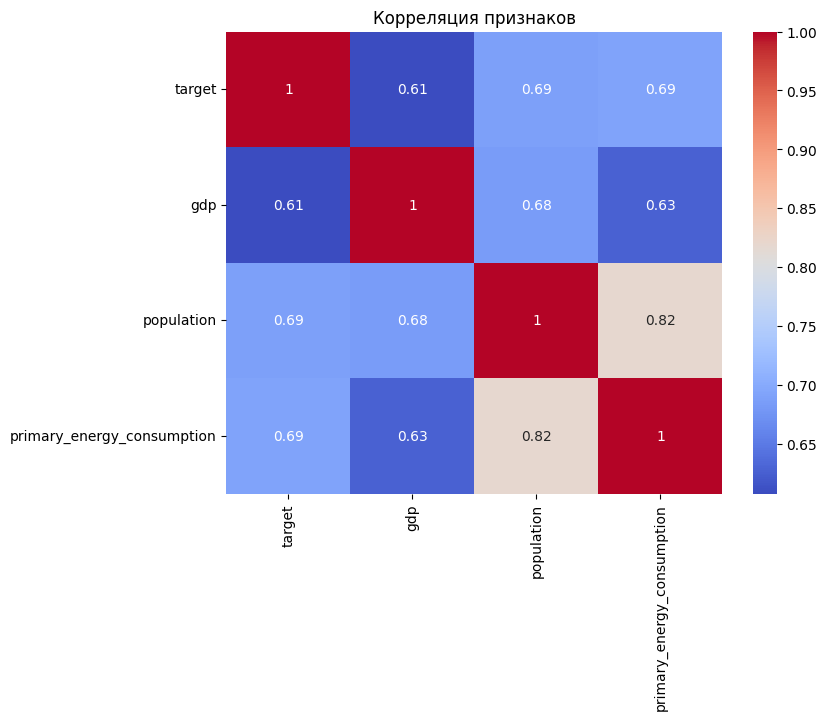

In [6]:
# 🔥 универсальный способ
df = pd.DataFrame(ts_data).reset_index()

# берём только нужные признаки (очень важно)
cols = ["target", "gdp", "population", "primary_energy_consumption"]
cols = [c for c in cols if c in df.columns]

numeric_df = df[cols]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)

plt.title('Корреляция признаков')
plt.show()

/var/folders/9q/dszlp4qs36g7gh938slcqd6m0000gn/T/ipykernel_68623/3594942910.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='target', y='item_id', data=top_countries, palette='viridis')


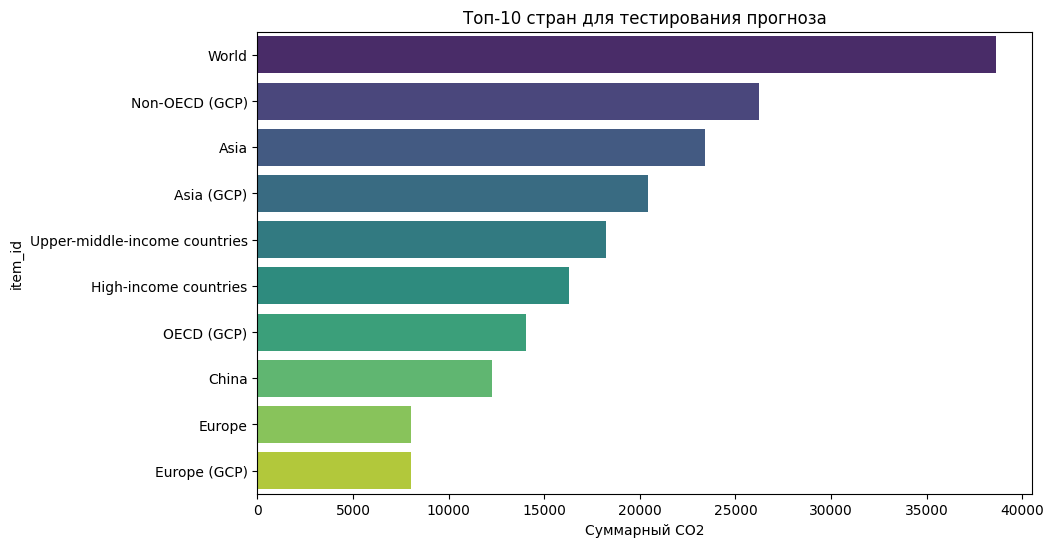

In [7]:
# 2. Топ-10 стран по суммарным выбросам
top_countries = df.groupby('item_id')['target'].max().nlargest(10).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='target', y='item_id', data=top_countries, palette='viridis')
plt.title('Топ-10 стран для тестирования прогноза')
plt.xlabel('Суммарный CO2')
plt.show()


In [8]:
# 3. Загрузка обученной модели и просмотр лидерборда
model = ForecastModel(model_path="models/ag_model_v1")
model.load()
lb = model.get_detailed_leaderboard()

# Выводим таблицу
display(lb)


,Model,MASE,Train Time (s),Predict Time (s)
0,WeightedEnsemble,-6.731139,0.227677,5.988980
1,RecursiveTabular,-7.111035,0.914251,0.044964
2,ETS,-7.438634,0.038517,1.502944
3,Chronos2,-7.670290,15.312018,2.619954
4,Theta,-7.936818,0.034945,0.210096
5,SeasonalNaive,-8.045419,0.027452,1.599693
6,TemporalFusionTransformer,-8.635588,122.490886,0.134768
7,DirectTabular,-21.171983,3.867658,0.083727


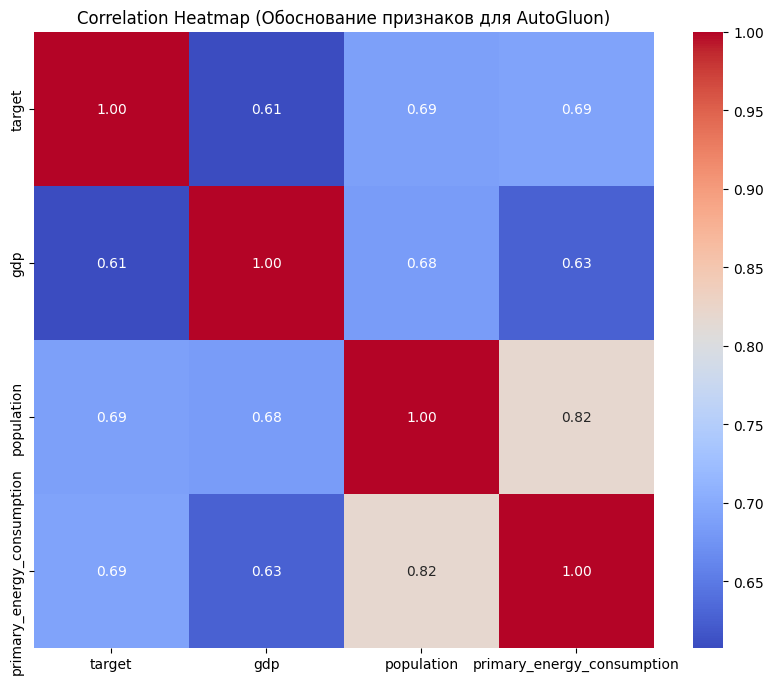

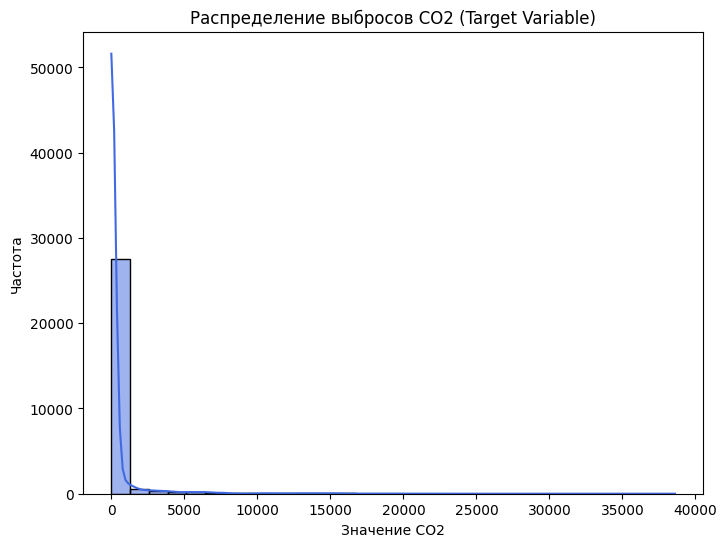

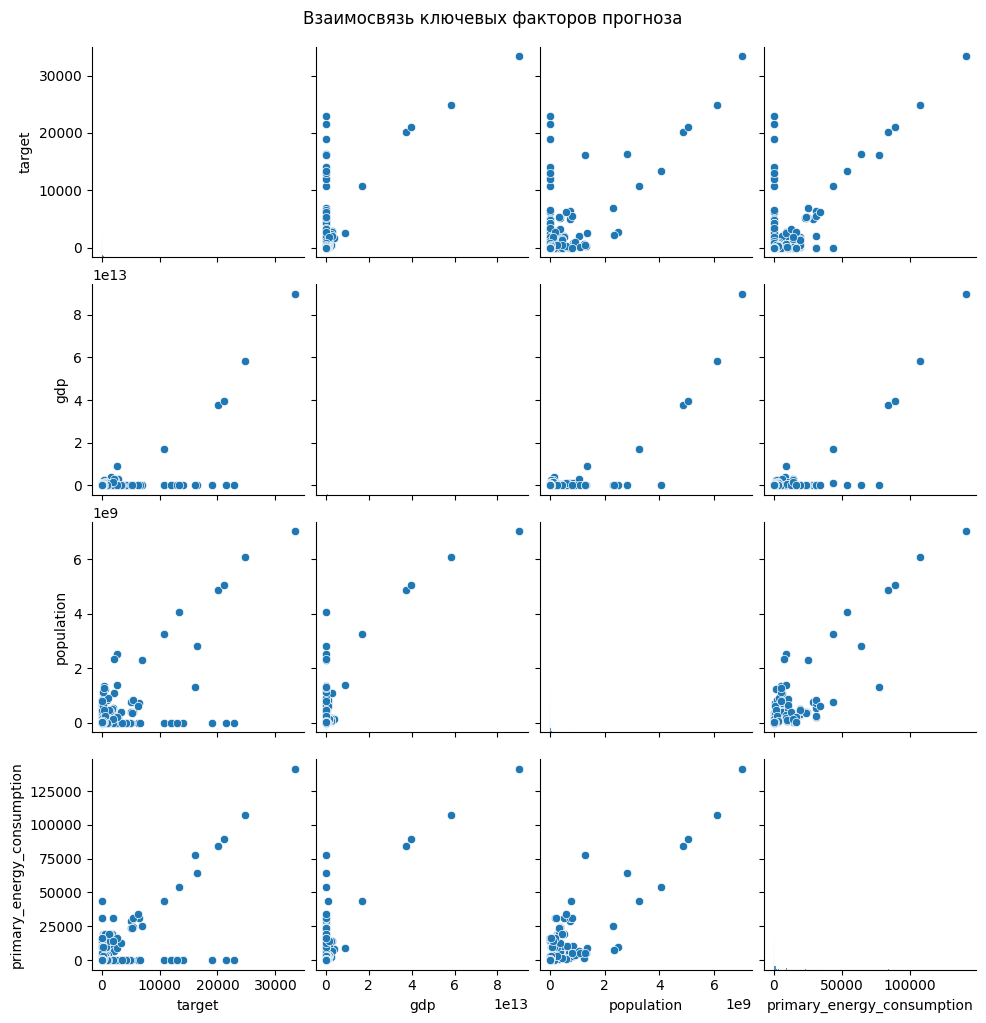

/var/folders/9q/dszlp4qs36g7gh938slcqd6m0000gn/T/ipykernel_68623/3783712833.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='target', y='item_id', data=top_countries, palette='magma')


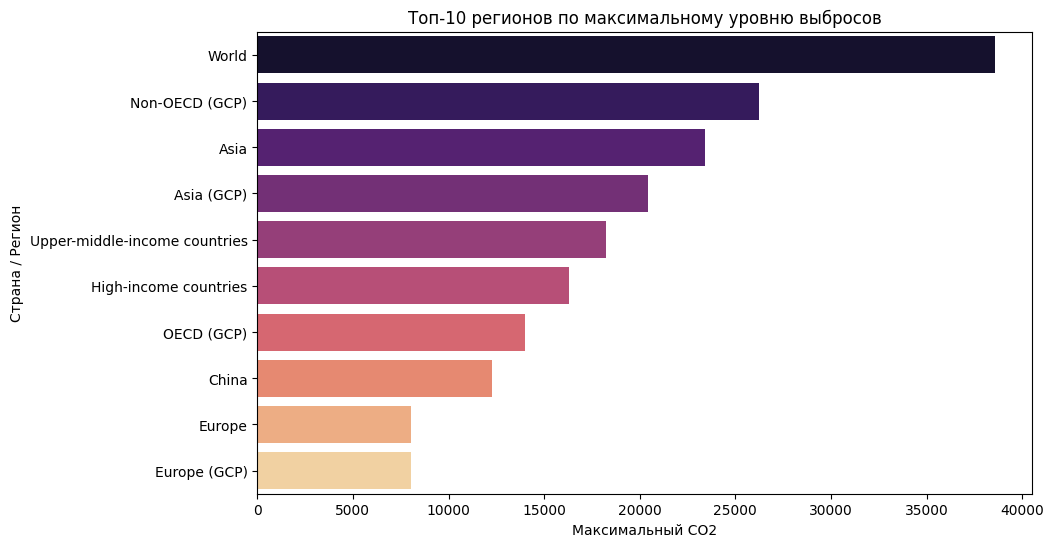

In [9]:
import numpy as np

# 1. Корреляционная матрица (Heatmap)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 2: # Уменьшил до 2, так как колонок после фильтрации меньше
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap (Обоснование признаков для AutoGluon)')
    plt.show()

# 2. Гистограмма распределения целевой переменной (target / co2)
plt.figure(figsize=(8, 6))
sns.histplot(df['target'].dropna(), kde=True, bins=30, color='royalblue')
plt.title('Распределение выбросов CO2 (Target Variable)')
plt.xlabel('Значение CO2')
plt.ylabel('Частота')
plt.show()

# 3. Pair Plot (Связи между параметрами)
# Выбираем только те колонки, которые реально есть в твоем df
cols_to_plot = [col for col in ['target', 'gdp', 'population', 'primary_energy_consumption'] if col in df.columns]
if len(cols_to_plot) > 1:
    sns.pairplot(df[cols_to_plot].sample(min(1000, len(df)))) # берем выборку 1000 точек для скорости
    plt.suptitle('Взаимосвязь ключевых факторов прогноза', y=1.02)
    plt.show()

# 4. Топ-10 стран по выбросам (Bar Plot)
# В твоем ts_data страна называется 'item_id'
if 'item_id' in df.columns:
    top_countries = df.groupby('item_id')['target'].max().nlargest(10).reset_index()
    plt.figure(figsize=(10, 6))
    sns.barplot(x='target', y='item_id', data=top_countries, palette='magma')
    plt.title('Топ-10 регионов по максимальному уровню выбросов')
    plt.xlabel('Максимальный CO2')
    plt.ylabel('Страна / Регион')
    plt.show()
